✅ HMI dataset ready: X=(10, 5, 128, 128), Y=(10, 3)


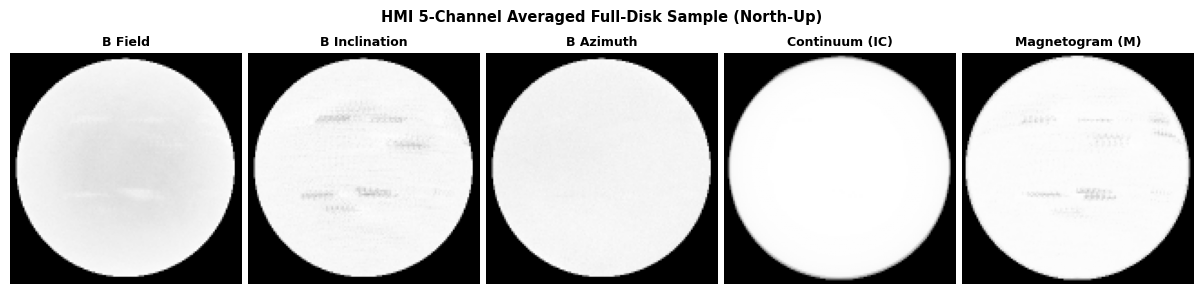

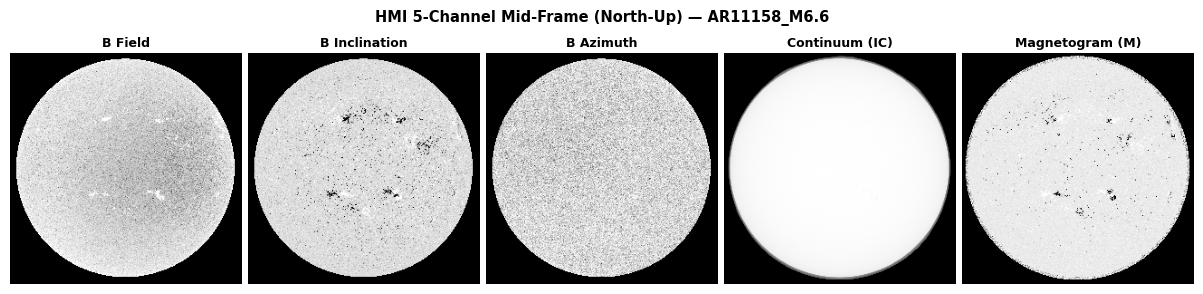

✅ Saved + reloaded OK: X=(10, 5, 128, 128), Y=(10, 3)


In [1]:
# %%
# ============================================================
# ☀️ HMI-only Preprocessing (Final, North-Up Verified)
# ============================================================
# • Aggregates all npz_hmi/*.npz per flare (daily averaged maps)
# • NaN-safe normalization (1–99%) + log stretch
# • Flips vertically (south-up → north-up, confirmed by CROTA2≈180°)
# • Saves training arrays to preprocessed_data/
# • Includes averaged & mid-frame visualizations
# ============================================================

import os, glob, numpy as np, pandas as pd, cv2, matplotlib.pyplot as plt

TARGET_CSV = "flare_euv_targets_3day.csv"
IMG_SIZE = 128  # you can raise to 192 for final paper runs

HMI_CHANNELS = ["hmiB_field","hmiB_incl","hmiB_azim","hmiIC","hmiM"]

# ============================================================
# 🔧 Normalization + Resize
# ============================================================
def normalize_log(img):
    f = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
    lo, hi = np.percentile(f, 1), np.percentile(f, 99)
    f = np.clip(f, lo, hi)
    f = np.log1p(f - lo + 1e-6)
    return f

def resize(img):
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

# ============================================================
# 🧩 Aggregate all npz per flare
# ============================================================
def aggregate_npz(folder, chans):
    files = sorted(glob.glob(os.path.join(folder, "*.npz")))
    if not files: return {}
    acc = {c: [] for c in chans}
    for f in files:
        d = np.load(f)
        for ch in chans:
            if ch in d:
                frame = d[ch].mean(axis=0)   # average within window
                frame = normalize_log(frame)
                frame = np.flipud(frame)     # ✅ south-up → north-up
                frame = resize(frame)
                acc[ch].append(frame)
    return {ch: np.mean(np.stack(v,0),0) for ch,v in acc.items() if v}

# ============================================================
# 📂 Build dataset
# ============================================================
targets = pd.read_csv(TARGET_CSV)
X, Y, skips = [], [], []

for flare in targets["flare_id"]:
    npz_dir = os.path.join(flare, "full_disk", "npz_hmi")
    maps = aggregate_npz(npz_dir, HMI_CHANNELS)
    if len(maps) < len(HMI_CHANNELS):
        skips.append(flare)
        continue
    stack = np.stack([maps[ch] for ch in HMI_CHANNELS], 0)
    X.append(stack)
    y = targets.loc[targets.flare_id==flare, ["EUV_T0","EUV_T1","EUV_T2"]].values[0]
    Y.append(y)

X, Y = np.array(X, np.float32), np.array(Y, np.float32)
print(f"✅ HMI dataset ready: X={X.shape}, Y={Y.shape}")
if skips: print("⚠️ Skipped:", skips)

# ============================================================
# 🔍 Visualization — Averaged vs Mid-Frame
# ============================================================
def show_hmi_avg(sample_idx=0):
    titles = ["B Field","B Inclination","B Azimuth","Continuum (IC)","Magnetogram (M)"]
    plt.figure(figsize=(12,3))
    for i in range(len(HMI_CHANNELS)):
        plt.subplot(1,5,i+1)
        plt.imshow(X[sample_idx,i], cmap="gray", origin="lower")
        plt.title(titles[i], fontsize=9, fontweight="bold", pad=5)
        plt.axis("off"); plt.gca().set_facecolor("black")
    plt.suptitle("HMI 5-Channel Averaged Full-Disk Sample (North-Up)",
                 fontsize=10.5, weight="bold", y=0.99)
    plt.tight_layout(pad=0.6,w_pad=0.5)
    plt.show()

def show_hmi_mid(flare_id):
    npz_dir = os.path.join(flare_id,"full_disk","npz_hmi")
    first_file = sorted(glob.glob(os.path.join(npz_dir,"*.npz")))[0]
    d = np.load(first_file)
    titles = ["B Field","B Inclination","B Azimuth","Continuum (IC)","Magnetogram (M)"]
    plt.figure(figsize=(12,3))
    for i,ch in enumerate(HMI_CHANNELS):
        if ch not in d: continue
        arr = d[ch]; mid = arr.shape[0] // 2
        f = np.nan_to_num(arr[mid])
        lo,hi = np.percentile(f,1),np.percentile(f,99)
        f = (np.clip(f,lo,hi)-lo)/(hi-lo+1e-6)
        f = np.flipud(f)
        plt.subplot(1,5,i+1)
        plt.imshow(f, cmap="gray", origin="lower")
        plt.title(titles[i], fontsize=9, fontweight="bold", pad=5)
        plt.axis("off"); plt.gca().set_facecolor("black")
    plt.suptitle(f"HMI 5-Channel Mid-Frame (North-Up) — {flare_id}",
                 fontsize=10.5, weight="bold", y=0.99)
    plt.tight_layout(pad=0.6,w_pad=0.5)
    plt.show()

# Example check
show_hmi_avg(0)
show_hmi_mid("AR11158_M6.6")

# ============================================================
# 💾 Save + Reload check
# ============================================================
SAVE_DIR = "preprocessed_data"
os.makedirs(SAVE_DIR, exist_ok=True)
np.save(os.path.join(SAVE_DIR,"X_hmi_only.npy"), X)
np.save(os.path.join(SAVE_DIR,"Y_hmi_only.npy"), Y)

# reload check
Xc = np.load(os.path.join(SAVE_DIR,"X_hmi_only.npy"))
Yc = np.load(os.path.join(SAVE_DIR,"Y_hmi_only.npy"))
print(f"✅ Saved + reloaded OK: X={Xc.shape}, Y={Yc.shape}")
